<a href="https://colab.research.google.com/github/manavsharma111/Machine-Learning/blob/main/GAMES_SETTINGS_OPTIMIZER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import random
import pandas as pd

# CPU list
cpus = [
    # --- INTEL CORE ULTRA SERIES 2 (Arrow Lake / Lunar Lake) ---
    {"brand": "Intel", "name": "Core Ultra 9 285K", "geekbench_sc": 3199, "cinebench_r23_sc": 2320},
    {"brand": "Intel", "name": "Core Ultra 7 265K", "geekbench_sc": 3085, "cinebench_r23_sc": 2304},
    {"brand": "Intel", "name": "Core Ultra 7 265KF", "geekbench_sc": 3085, "cinebench_r23_sc": 2304},
    {"brand": "Intel", "name": "Core Ultra 5 245K", "geekbench_sc": 2900, "cinebench_r23_sc": 2150},
    {"brand": "Intel", "name": "Core Ultra 5 245KF", "geekbench_sc": 2900, "cinebench_r23_sc": 2150},
    {"brand": "Intel", "name": "Core Ultra 5 225", "geekbench_sc": 2700, "cinebench_r23_sc": 1950},
    {"brand": "Intel", "name": "Core Ultra 5 225F", "geekbench_sc": 2700, "cinebench_r23_sc": 1950},
    {"brand": "Intel", "name": "Core Ultra 9 288V", "geekbench_sc": 2850, "cinebench_r23_sc": 2050},
    {"brand": "Intel", "name": "Core Ultra 7 268V", "geekbench_sc": 2780, "cinebench_r23_sc": 1995},
    {"brand": "Intel", "name": "Core Ultra 7 266V", "geekbench_sc": 2760, "cinebench_r23_sc": 1985},
    {"brand": "Intel", "name": "Core Ultra 7 258V", "geekbench_sc": 2750, "cinebench_r23_sc": 1980},
    {"brand": "Intel", "name": "Core Ultra 7 256V", "geekbench_sc": 2750, "cinebench_r23_sc": 1980},
    {"brand": "Intel", "name": "Core Ultra 5 238V", "geekbench_sc": 2650, "cinebench_r23_sc": 1880},
    {"brand": "Intel", "name": "Core Ultra 5 236V", "geekbench_sc": 2650, "cinebench_r23_sc": 1880},
    {"brand": "Intel", "name": "Core Ultra 5 228V", "geekbench_sc": 2600, "cinebench_r23_sc": 1850},
    {"brand": "Intel", "name": "Core Ultra 5 226V", "geekbench_sc": 2600, "cinebench_r23_sc": 1850},

    # --- AMD RYZEN 9000 SERIES (Zen 5 Desktop) ---
    {"brand": "AMD", "name": "Ryzen 9 9950X", "geekbench_sc": 3350, "cinebench_r23_sc": 2320},
    {"brand": "AMD", "name": "Ryzen 9 9900X", "geekbench_sc": 3338, "cinebench_r23_sc": 2290},
    {"brand": "AMD", "name": "Ryzen 7 9800X3D", "geekbench_sc": 3336, "cinebench_r23_sc": 2250},
    {"brand": "AMD", "name": "Ryzen 7 9700X", "geekbench_sc": 3312, "cinebench_r23_sc": 2210},
    {"brand": "AMD", "name": "Ryzen 5 9600X", "geekbench_sc": 3284, "cinebench_r23_sc": 2180},

    # --- AMD RYZEN AI 300 SERIES (Zen 5 Laptop) ---
    {"brand": "AMD", "name": "Ryzen AI 9 HX 370", "geekbench_sc": 2850, "cinebench_r23_sc": 2040},
    {"brand": "AMD", "name": "Ryzen AI 9 365", "geekbench_sc": 2780, "cinebench_r23_sc": 1920},

    # --- INTEL 14th GEN (Raptor Lake Refresh) ---
    {"brand": "Intel", "name": "Core i9-14900KS", "geekbench_sc": 3150, "cinebench_r23_sc": 2310},
    {"brand": "Intel", "name": "Core i9-14900K", "geekbench_sc": 3125, "cinebench_r23_sc": 2293},
    {"brand": "Intel", "name": "Core i9-14900KF", "geekbench_sc": 3125, "cinebench_r23_sc": 2293},
    {"brand": "Intel", "name": "Core i7-14700K", "geekbench_sc": 2980, "cinebench_r23_sc": 2204},
    {"brand": "Intel", "name": "Core i7-14700KF", "geekbench_sc": 2980, "cinebench_r23_sc": 2204},
    {"brand": "Intel", "name": "Core i5-14600K", "geekbench_sc": 2850, "cinebench_r23_sc": 2085},
    {"brand": "Intel", "name": "Core i5-14600KF", "geekbench_sc": 2850, "cinebench_r23_sc": 2085},
    {"brand": "Intel", "name": "Core i5-14400", "geekbench_sc": 2450, "cinebench_r23_sc": 1750},
    {"brand": "Intel", "name": "Core i3-14100", "geekbench_sc": 2250, "cinebench_r23_sc": 1600},
    {"brand": "Intel", "name": "Core i9-14900HX", "geekbench_sc": 2900, "cinebench_r23_sc": 2150},
    {"brand": "Intel", "name": "Core i7-14700HX", "geekbench_sc": 2750, "cinebench_r23_sc": 2000},
    {"brand": "Intel", "name": "Core i7-14650HX", "geekbench_sc": 2680, "cinebench_r23_sc": 1950},
    {"brand": "Intel", "name": "Core i5-14500HX", "geekbench_sc": 2550, "cinebench_r23_sc": 1850},
    {"brand": "Intel", "name": "Core i5-14450HX", "geekbench_sc": 2400, "cinebench_r23_sc": 1750},
    {"brand": "Intel", "name": "Core 7 150U", "geekbench_sc": 2350, "cinebench_r23_sc": 1600},
    {"brand": "Intel", "name": "Core 5 120U", "geekbench_sc": 2150, "cinebench_r23_sc": 1450},

    # --- AMD RYZEN 8000 & 7000 SERIES (Zen 4) ---
    {"brand": "AMD", "name": "Ryzen 9 7950X", "geekbench_sc": 2950, "cinebench_r23_sc": 2050},
    {"brand": "AMD", "name": "Ryzen 9 7900X", "geekbench_sc": 2920, "cinebench_r23_sc": 2020},
    {"brand": "AMD", "name": "Ryzen 7 7800X3D", "geekbench_sc": 2624, "cinebench_r23_sc": 1780},
    {"brand": "AMD", "name": "Ryzen 7 7700X", "geekbench_sc": 2880, "cinebench_r23_sc": 1980},
    {"brand": "AMD", "name": "Ryzen 5 7600X", "geekbench_sc": 2820, "cinebench_r23_sc": 1940},
    {"brand": "AMD", "name": "Ryzen 9 7945HX", "geekbench_sc": 2800, "cinebench_r23_sc": 1930},
    {"brand": "AMD", "name": "Ryzen 9 8945HS", "geekbench_sc": 2680, "cinebench_r23_sc": 1850},
    {"brand": "AMD", "name": "Ryzen 7 8845HS", "geekbench_sc": 2610, "cinebench_r23_sc": 1790},
    {"brand": "AMD", "name": "Ryzen 7 8700G", "geekbench_sc": 2650, "cinebench_r23_sc": 1820},
    {"brand": "AMD", "name": "Ryzen 7 7735U", "geekbench_sc": 2150, "cinebench_r23_sc": 1490},

    # --- INTEL 13th & 12th GEN (Raptor/Alder Lake) ---
    {"brand": "Intel", "name": "Core i9-13900K", "geekbench_sc": 3070, "cinebench_r23_sc": 2282},
    {"brand": "Intel", "name": "Core i7-13700K", "geekbench_sc": 2880, "cinebench_r23_sc": 2125},
    {"brand": "Intel", "name": "Core i9-12900K", "geekbench_sc": 2750, "cinebench_r23_sc": 2014},
    {"brand": "Intel", "name": "Core i7-12700H", "geekbench_sc": 2450, "cinebench_r23_sc": 1820},

    # --- AMD RYZEN 5000 SERIES (Zen 3) ---
    {"brand": "AMD", "name": "Ryzen 9 5950X", "geekbench_sc": 2100, "cinebench_r23_sc": 1640},
    {"brand": "AMD", "name": "Ryzen 9 5900X", "geekbench_sc": 2050, "cinebench_r23_sc": 1610},
    {"brand": "AMD", "name": "Ryzen 7 5800X", "geekbench_sc": 1980, "cinebench_r23_sc": 1590},
    {"brand": "AMD", "name": "Ryzen 9 5900HX", "geekbench_sc": 1820, "cinebench_r23_sc": 1500},
    {"brand": "AMD", "name": "Ryzen 7 5800H", "geekbench_sc": 1750, "cinebench_r23_sc": 1450},

    # --- INTEL 11th & 10th GEN (Legacy) ---
    {"brand": "Intel", "name": "Core i9-11900K", "geekbench_sc": 2150, "cinebench_r23_sc": 1627},
    {"brand": "Intel", "name": "Core i9-10900K", "geekbench_sc": 1650, "cinebench_r23_sc": 1346},
    {"brand": "Intel", "name": "Core i7-10750H", "geekbench_sc": 1450, "cinebench_r23_sc": 1250}
]

# GPU list
gpus = [
    # --- NVIDIA RTX 50 SERIES (Blackwell - Desktop & Laptop) ---
    {"brand": "NVIDIA", "name": "RTX 5090", "opencl": 385000, "cinebench": 42000, "vram": "32GB", "tgp": "600W", "upscale": "DLSS 4.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 5080 Super", "opencl": 310000, "cinebench": 33000, "vram": "20GB", "tgp": "450W", "upscale": "DLSS 4.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 5080", "opencl": 295000, "cinebench": 31500, "vram": "16GB", "tgp": "400W", "upscale": "DLSS 4.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 5070 Ti", "opencl": 235000, "cinebench": 25000, "vram": "16GB", "tgp": "300W", "upscale": "DLSS 4.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 5070", "opencl": 195000, "cinebench": 21000, "vram": "12GB", "tgp": "250W", "upscale": "DLSS 4.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 5060", "opencl": 130000, "cinebench": 13500, "vram": "8GB", "tgp": "170W", "upscale": "DLSS 4.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 5090 (Laptop)", "opencl": 245000, "cinebench": 26000, "vram": "16GB", "tgp": "175W", "upscale": "DLSS 4.5/FSR", "type": "Laptop"},

    # --- NVIDIA RTX 40 SERIES (Ada Lovelace) ---
    {"brand": "NVIDIA", "name": "RTX 4090", "opencl": 320000, "cinebench": 35500, "vram": "24GB", "tgp": "450W", "upscale": "DLSS 3.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 4080 Ti", "opencl": 275000, "cinebench": 30000, "vram": "20GB", "tgp": "350W", "upscale": "DLSS 3.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 4080", "opencl": 250000, "cinebench": 27500, "vram": "16GB", "tgp": "320W", "upscale": "DLSS 3.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 4070 Ti", "opencl": 200000, "cinebench": 22000, "vram": "12GB", "tgp": "285W", "upscale": "DLSS 3.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 4070", "opencl": 175000, "cinebench": 18500, "vram": "12GB", "tgp": "200W", "upscale": "DLSS 3.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 4060 Ti", "opencl": 135000, "cinebench": 13500, "vram": "8GB/16GB", "tgp": "160W", "upscale": "DLSS 3.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 4060", "opencl": 105000, "cinebench": 10500, "vram": "8GB", "tgp": "115W", "upscale": "DLSS 3.5/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 4090 (Laptop)", "opencl": 215000, "cinebench": 22500, "vram": "16GB", "tgp": "175W", "upscale": "DLSS 3.5/FSR", "type": "Laptop"},
    {"brand": "NVIDIA", "name": "RTX 4080 (Laptop)", "opencl": 185000, "cinebench": 19000, "vram": "12GB", "tgp": "175W", "upscale": "DLSS 3.5/FSR", "type": "Laptop"},
    {"brand": "NVIDIA", "name": "RTX 4070 (Laptop)", "opencl": 125000, "cinebench": 11500, "vram": "8GB", "tgp": "115W", "upscale": "DLSS 3.5/FSR", "type": "Laptop"},
    {"brand": "NVIDIA", "name": "RTX 4060 (Laptop)", "opencl": 105000, "cinebench": 10200, "vram": "8GB", "tgp": "115W", "upscale": "DLSS 3.5/FSR", "type": "Laptop"},
    {"brand": "NVIDIA", "name": "RTX 4050 (Laptop)", "opencl": 85000, "cinebench": 7500, "vram": "6GB", "tgp": "115W", "upscale": "DLSS 3.5/FSR", "type": "Laptop"},

    # --- NVIDIA RTX 30 SERIES (Ampere) ---
    {"brand": "NVIDIA", "name": "RTX 3090", "opencl": 230000, "cinebench": 23500, "vram": "24GB", "tgp": "350W", "upscale": "DLSS 2/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 3080 Super", "opencl": 195000, "cinebench": 19000, "vram": "12GB", "tgp": "350W", "upscale": "DLSS 2/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 3080", "opencl": 185000, "cinebench": 17500, "vram": "10GB", "tgp": "320W", "upscale": "DLSS 2/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 3070 Ti", "opencl": 155000, "cinebench": 15000, "vram": "8GB", "tgp": "290W", "upscale": "DLSS 2/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 3070", "opencl": 145000, "cinebench": 14000, "vram": "8GB", "tgp": "220W", "upscale": "DLSS 2/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 3060 Super", "opencl": 115000, "cinebench": 10500, "vram": "8GB", "tgp": "175W", "upscale": "DLSS 2/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 3060", "opencl": 95000, "cinebench": 9200, "vram": "12GB", "tgp": "170W", "upscale": "DLSS 2/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 3050", "opencl": 65000, "cinebench": 5500, "vram": "8GB", "tgp": "130W", "upscale": "DLSS 2/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 3080 Ti (Laptop)", "opencl": 165000, "cinebench": 14500, "vram": "16GB", "tgp": "150W", "type": "Laptop"},
    {"brand": "NVIDIA", "name": "RTX 3070 Ti (Laptop)", "opencl": 135000, "cinebench": 12500, "vram": "8GB", "tgp": "125W", "type": "Laptop"},
    {"brand": "NVIDIA", "name": "RTX 3060 (Laptop)", "opencl": 92000, "cinebench": 8500, "vram": "6GB", "tgp": "115W", "type": "Laptop"},
    {"brand": "NVIDIA", "name": "RTX 3050 (Laptop)", "opencl": 58000, "cinebench": 4200, "vram": "4GB", "tgp": "80W", "type": "Laptop"},

    # --- NVIDIA RTX 20 SERIES ---
    {"brand": "NVIDIA", "name": "RTX 2080 Ti", "opencl": 155000, "cinebench": 15500, "vram": "11GB", "tgp": "250W", "upscale": "DLSS 2/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 2070", "opencl": 105000, "cinebench": 9500, "vram": "8GB", "tgp": "175W", "upscale": "DLSS 2/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 2060", "opencl": 82000, "cinebench": 7500, "vram": "6GB", "tgp": "160W", "upscale": "DLSS 2/FSR", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "RTX 2050 (Laptop)", "opencl": 48000, "cinebench": 3800, "vram": "4GB", "tgp": "45W", "type": "Laptop"},

    # --- NVIDIA GTX SERIES ---
    {"brand": "NVIDIA", "name": "GTX 1660 Ti Super", "opencl": 65000, "cinebench": 4800, "vram": "6GB", "tgp": "125W", "upscale": "FSR Only", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "GTX 1660 Ti", "opencl": 62000, "cinebench": 4500, "vram": "6GB", "tgp": "120W", "upscale": "FSR Only", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "GTX 1660 Super", "opencl": 60000, "cinebench": 4200, "vram": "6GB", "tgp": "125W", "upscale": "FSR Only", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "GTX 1660", "opencl": 55000, "cinebench": 3800, "vram": "6GB", "tgp": "120W", "upscale": "FSR Only", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "GTX 1650 Ti", "opencl": 45000, "cinebench": 3200, "vram": "4GB", "tgp": "100W", "upscale": "FSR Only", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "GTX 1650 Super", "opencl": 42000, "cinebench": 3000, "vram": "4GB", "tgp": "100W", "upscale": "FSR Only", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "GTX 1650", "opencl": 38000, "cinebench": 2800, "vram": "4GB", "tgp": "75W", "upscale": "FSR Only", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "GTX 1080 Ti", "opencl": 115000, "cinebench": 10500, "vram": "11GB", "tgp": "250W", "upscale": "FSR Only", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "GTX 1070", "opencl": 75000, "cinebench": 6500, "vram": "8GB", "tgp": "150W", "upscale": "FSR Only", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "GTX 1060", "opencl": 42000, "cinebench": 3200, "vram": "6GB", "tgp": "120W", "upscale": "FSR Only", "type": "Desktop"},
    {"brand": "NVIDIA", "name": "GTX 1050", "opencl": 28000, "cinebench": 1800, "vram": "2GB", "tgp": "75W", "upscale": "FSR Only", "type": "Desktop"},

    # --- AMD RADEON (Famous Desktop & Laptop) ---
    {"brand": "AMD", "name": "Radeon RX 7900 XTX", "opencl": 215000, "cinebench": 14500, "vram": "24GB", "tgp": "355W", "upscale": "FSR 3/AFMF", "type": "Desktop"},
    {"brand": "AMD", "name": "Radeon RX 7800 XT", "opencl": 155000, "cinebench": 9800, "vram": "16GB", "tgp": "263W", "upscale": "FSR 3/AFMF", "type": "Desktop"},
    {"brand": "AMD", "name": "Radeon RX 7900M (Laptop)", "opencl": 185000, "cinebench": 12500, "vram": "16GB", "tgp": "180W", "upscale": "FSR 3/AFMF", "type": "Laptop"},
    {"brand": "AMD", "name": "Radeon RX 6800M (Laptop)", "opencl": 145000, "cinebench": 10500, "vram": "12GB", "tgp": "145W", "upscale": "FSR 3/AFMF", "type": "Laptop"},
    {"brand": "AMD", "name": "Radeon RX 580", "opencl": 45000, "cinebench": 2500, "vram": "8GB", "tgp": "185W", "upscale": "FSR 2.2", "type": "Desktop"}
]

games = [
    "Resident Evil 2 Remake","Resident Evil 3 Remake","Resident Evil 4 Remake","Resident Evil 7","Resident Evil 8","Resident Evil 9",
    "God of War","Ghost of Tsushima","Days Gone Remake",
    "Devil May Cry 5","Uncharted 4","Red Dead Redemption 2",
    "Last of Us Part I Remake","Last of Us Part II Remake",
    "Cyberpunk 2077","Mortal Kombat 1","Tekken 7","Tekken 8",
    "Elden Ring","Elden Ring: Shadow of the Erdtree",
    "Grand Theft Auto V","Silent Hill f",
    "Assassin's Creed IV: Black Flag","Metal Gear Solid V",
    "Dark Souls Remastered","Dark Souls 2","Dark Souls 3",
    "Watch Dogs 2","Tomb Raider (2013)","Rise of the Tomb Raider","Shadow of the Tomb Raider",
    "The Evil Within","The Evil Within 2",
    "Far Cry 3","Far Cry 4","Far Cry 5",
    "Sekiro",
    "The Witcher 3: Wild Hunt", "Horizon Zero Dawn", "Horizon Forbidden West", "Marvel's Spider-Man Remastered", "Marvel's Spider-Man: Miles Morales",
    "Batman: Arkham Knight", "Mad Max", "Control", "Dishonored 2", "Prey (2017)", "Deus Ex: Mankind Divided",
    "Hitman 3", "Death Stranding", "Resident Evil Village", "God of War Ragnarök", "Assassin's Creed Valhalla", "Assassin's Creed Odyssey", "Assassin's Creed Origins",
    "Star Wars Jedi: Fallen Order", "Star Wars Jedi: Survivor", "Marvel's Guardians of the Galaxy", "Mass Effect Legendary Edition",
    "DOOM Eternal", "Wolfenstein II: The New Colossus", "Metro Exodus", "Dying Light 2 Stay Human", "Borderlands 3", "Tiny Tina's Wonderlands",
    "Diablo IV", "Hogwarts Legacy", "Forza Horizon 5", "Microsoft Flight Simulator", "Assetto Corsa Competizione",
    "Baldur's Gate 3", "Starfield", "Hades", "Persona 5 Royal", "Final Fantasy VII Remake", "Final Fantasy XV",
    "Gears 5", "Halo Infinite", "Apex Legends", "Call of Duty: Warzone", "Fortnite", "Valorant", "Overwatch 2",
    "Minecraft", "Roblox", "League of Legends", "Dota 2", "Counter-Strike 2", "Rainbow Six Siege", "Valorant",
    "Among Us", "Phasmophobia", "Grand Theft Auto Online", "Red Dead Online",
    "The Elder Scrolls V: Skyrim", "Fallout 4", "Fallout 76", "Starfield",
    "Cyberpunk 2077: Phantom Liberty", "Doom Eternal: The Ancient Gods",
    "Control: Ultimate Edition", "Deathloop", "Dishonored: Death of the Outsider",
    "Fable (Upcoming)", "State of Decay 3 (Upcoming)", "Everwild (Upcoming)", "Avowed (Upcoming)",
    "Payday 3", "S.T.A.L.K.E.R. 2", "ARK: Survival Evolved", "Palworld", "New World", "V Rising",
    "Crusader Kings 3", "Europa Universalis 4", "Victoria 3", "Hearts of Iron 4",
    "Sid Meier's Civilization VI", "Age of Empires IV", "Company of Heroes 3",
    "F1 23", "EA Sports FC 24", "NBA 2K24", "Madden NFL 24", "NHL 24", "Gran Turismo 7",
    "God of War (PC)", "Marvel's Spider-Man (PC)", "Uncharted: Legacy of Thieves Collection (PC)",
    "Horizon Zero Dawn (PC)", "Days Gone (PC)", "Death Stranding (PC)",
    "Forza Motorsport", "Microsoft Flight Simulator 2024",
    "The Finals", "Helldivers 2", "Palworld", "Dragon's Dogma 2", "Rise of the Ronin",
    "Black Myth: Wukong", "Warzone Mobile", "Honkai Star Rail", "Genshin Impact",
    "Baldur's Gate 3", "Starfield", "Cities: Skylines II",
    "Street Fighter 6", "Mortal Kombat 1", "Tekken 8", "Granblue Fantasy Versus: Rising",
    "Final Fantasy VII Rebirth", "Persona 3 Reload", "Like a Dragon: Infinite Wealth",
    "Suicide Squad: Kill the Justice League", "Skull and Bones", "Prince of Persia: The Lost Crown",
    "Avatar: Frontiers of Pandora", "The Division 3", "Star Wars Outlaws",
    "Sons of the Forest", "Rust", "Escape from Tarkov", "DayZ", "ARK: Survival Ascended",
    "League of Legends", "Dota 2", "Overwatch 2", "Apex Legends", "Valorant", "Counter-Strike 2",
    "Rocket League", "Fortnite", "PUBG: Battlegrounds", "Call of Duty: Warzone",
    "Minecraft", "Roblox", "Grand Theft Auto V", "Red Dead Redemption 2",
    "The Witcher 3: Wild Hunt", "The Elder Scrolls V: Skyrim", "Fallout 4",
    "Doom Eternal", "Halo Infinite", "Gears 5",
    "Forza Horizon 5", "Need for Speed Unbound",
    "Cyberpunk 2077", "Hogwarts Legacy", "Baldur's Gate 3", "Alan Wake 2",
    "Lies of P", "Remnant 2", "Star Wars Jedi: Survivor",
    "Diablo IV", "Path of Exile", "Lost Ark",
    "Terraria", "Stardew Valley", "Factorio",
    "Sea of Thieves", "Rust", "Among Us",
    "Phasmophobia", "GTFO", "Ready or Not",
    "Assetto Corsa Competizione", "F1 23", "EA Sports FC 24",
    "NBA 2K24", "Madden NFL 24", "NHL 24",
    "Tekken 8", "Street Fighter 6", "Mortal Kombat 1",
    "Super Smash Bros. Ultimate", "Mario Kart 8 Deluxe",
    "Pokemon Scarlet and Violet", "The Legend of Zelda: Tears of the Kingdom",
    "Final Fantasy XIV", "World of Warcraft", "Guild Wars 2",
    "War Thunder", "World of Tanks", "Star Citizen", "EVE Online",
    "No Man's Sky", "Elite Dangerous",
    "Kerbal Space Program 2", "Satisfactory",
    "Deep Rock Galactic", "Vermintide 2", "Darktide",
    "Age of Empires II: Definitive Edition", "Age of Mythology: Retold",
    "Total War: Warhammer III", "Crusader Kings III",
    "Mount & Blade II: Bannerlord", "Kingdom Come: Deliverance",
    "Project Zomboid", "Valheim", "Grounded",
    "Scum", "Conan Exiles", "DayZ",
    "V Rising", "Sons of the Forest", "Enshrouded",
    "Green Hell", "Raft", "Subnautica",
    "Amnesia: The Bunker", "Outlast Trials", "SOMA",
    "Dead by Daylight", "Phasmophobia", "Lethal Company",
    "Fall Guys", "Among Us", "Goose Goose Duck",
    "Stray", "Cult of the Lamb", "PlateUp!",
    "PowerWash Simulator", "Dredge", "Dave the Diver",
    "Hi-Fi Rush", "Pentiment", "Disco Elysium",
    "Death's Door", "Hades", "Celeste", "Hollow Knight",
    "Ori and the Blind Forest", "Ori and the Will of the Wisps",
    "Cuphead", "Blasphemous", "Darkest Dungeon",
    "Slay the Spire", "Binding of Isaac Rebirth",
    "Factorio", "Satisfactory", "Dyson Sphere Program",
    "Cities: Skylines", "Planet Coaster", "Two Point Hospital",
    "Cooking Simulator", "House Flipper", "PC Building Simulator",
    "The Sims 4", "Cities: Skylines 2", "Farming Simulator 22",
    "PowerWash Simulator", "Microsoft Flight Simulator", "Forza Motorsport",
    "Assetto Corsa Competizione", "iRacing", "BeamNG.drive",
    "Project CARS 3", "WRC Generations", "Dirt Rally 2.0"
]

# Other parameters for random generation
resolutions = ['1920x1080', '2560x1440', '3840x2160']
refresh_rates = [60, 75, 120, 144, 165, 240, 360]
ram_sizes = [8, 16, 32, 64]

graphics_settings = ['Low', 'Medium', 'High', 'Ultra']
shadow_qualities = ['Low', 'Medium', 'High', 'Ultra']
anti_aliasing_modes = ['Off', 'FXAA', 'TAA', 'MSAA 2x', 'MSAA 4x', 'MSAA 8x', 'SSAA', 'MMAA', 'SMAA']
antialiasing_transparency_modes = ['Off', '2x', '4x', '8x', '16x']
dlss_fsr_options = ['Off', 'Quality', 'Balanced', 'Performance']
ray_tracing_options = ['Off', 'Low', 'Medium', 'High']

nvidia_power_management_modes = ['Prefer maximum performance', 'Optimal power', 'Adaptive']
nvidia_low_latency_modes = ['Off', 'On', 'Ultra']
nvidia_texture_filtering_qualities = ['High performance', 'Performance', 'Quality', 'High Quality']

os_game_modes = ['On', 'Off']
os_hardware_accelerated_gpu_scheduling_options = ['On', 'Off']
os_power_plans = ['High Performance', 'Balanced', 'Power Saver']
preferred_graphics_processors = ['High-performance NVIDIA processor', 'Integrated graphics']

max_frame_rates = ['Off', '60', '75', '120', '144', '240'] # Can also be 'Off'
v_sync_modes = ['Off', 'On', 'Fast', 'Adaptive']
triple_buffering_options = ['Off', 'On']
shader_cache_sizes = ['Unlimited', '10GB', '100GB']
anisotropic_sample_optimization_options = ['On', 'Off']
threaded_optimization_options = ['Auto', 'On', 'Off']
image_scaling_nis_options = ['Off', 'On']
in_game_overlay_options = ['Enabled', 'Disabled']
whisper_mode_options = ['Off', 'On']
battery_boost_options = ['Off', 'On']

# --- Data Generation ---
num_entries = 2000 # Number of synthetic data entries
data = []

for _ in range(num_entries):
    cpu = random.choice(cpus)
    gpu = random.choice(gpus)
    game = random.choice(games)

    resolution = random.choice(resolutions)
    refresh_rate = random.choice(refresh_rates)
    ram_size = random.choice(ram_sizes)

    graphics_setting = random.choice(graphics_settings)
    shadow_quality = random.choice(shadow_qualities)
    anti_aliasing_mode = random.choice(anti_aliasing_modes)
    antialiasing_transparency = random.choice(antialiasing_transparency_modes)
    dlss_fsr = random.choice(dlss_fsr_options)
    ray_tracing = random.choice(ray_tracing_options)

    # NVIDIA specific settings (simplified, assuming they apply to any GPU for data generation)
    nvidia_power_management_mode = random.choice(nvidia_power_management_modes)
    nvidia_low_latency_mode = random.choice(nvidia_low_latency_modes)
    nvidia_texture_filtering_quality = random.choice(nvidia_texture_filtering_qualities)

    # OS specific settings
    os_game_mode = random.choice(os_game_modes)
    os_hardware_accelerated_gpu_scheduling = random.choice(os_hardware_accelerated_gpu_scheduling_options)
    os_power_plan = random.choice(os_power_plans)
    preferred_graphics_processor = random.choice(preferred_graphics_processors)

    max_frame_rate = random.choice(max_frame_rates)
    v_sync = random.choice(v_sync_modes)
    triple_buffering = random.choice(triple_buffering_options)
    shader_cache_size = random.choice(shader_cache_sizes)
    anisotropic_sample_optimization = random.choice(anisotropic_sample_optimization_options)
    threaded_optimization = random.choice(threaded_optimization_options)
    image_scaling_nis = random.choice(image_scaling_nis_options)
    in_game_overlay = random.choice(in_game_overlay_options)
    whisper_mode = random.choice(whisper_mode_options)
    battery_boost = random.choice(battery_boost_options)

    # Simplified FPS calculation (arbitrary function for demonstration)
    # This is a placeholder; a real model would predict this more accurately
    base_fps = (cpu['geekbench_sc'] / 100) + (gpu['opencl'] / 5000)
    res_factor = {'1920x1080': 1.0, '2560x1440': 0.7, '3840x2160': 0.4}.get(resolution, 1.0)
    setting_factor = {'Low': 1.2, 'Medium': 1.0, 'High': 0.8, 'Ultra': 0.6}.get(graphics_setting, 1.0)
    dlss_factor = {'Off': 1.0, 'Quality': 1.1, 'Balanced': 1.2, 'Performance': 1.3}.get(dlss_fsr, 1.0)
    rt_factor = {'Off': 1.0, 'Low': 0.9, 'Medium': 0.8, 'High': 0.7}.get(ray_tracing, 1.0)

    fps = int(base_fps * res_factor * setting_factor * dlss_factor * rt_factor + random.randint(-20, 20))
    fps = max(20, fps) # Minimum FPS
    fps = min(400, fps) # Maximum FPS

    data.append([
        cpu['brand'], cpu['name'], cpu['geekbench_sc'],
        gpu['brand'], gpu['name'], gpu['opencl'], gpu['type'],
        gpu['vram'], gpu['tgp'], gpu.get('upscale', 'N/A'),
        ram_size, game, resolution, refresh_rate, graphics_setting, shadow_quality,
        anti_aliasing_mode, antialiasing_transparency, dlss_fsr, ray_tracing,
        nvidia_power_management_mode, nvidia_low_latency_mode, nvidia_texture_filtering_quality,
        os_game_mode, os_hardware_accelerated_gpu_scheduling, os_power_plan,
        preferred_graphics_processor, max_frame_rate, v_sync, triple_buffering,
        shader_cache_size, anisotropic_sample_optimization, threaded_optimization,
        image_scaling_nis, in_game_overlay, whisper_mode, battery_boost, fps
    ])

# Define columns for the DataFrame
columns = [
    'CPU_Brand', 'CPU_Name', 'CPU_Score',
    'GPU_Brand', 'GPU_Name', 'GPU_Score', 'GPU_Type',
    'VRAM', 'TGP', 'Upscale',
    'RAM_Size', 'Game_Name', 'Resolution', 'Refresh_Rate', 'Graphics_Settings', 'Shadow_Quality',
    'Anti_Aliasing_Mode', 'Antialiasing_Transparency', 'DLSS_FSR', 'Ray_Tracing',
    'NVIDIA_Power_Management_Mode', 'NVIDIA_Low_Latency_Mode', 'NVIDIA_Texture_Filtering_Quality',
    'OS_Game_Mode', 'OS_Hardware_Accelerated_GPU_Scheduling', 'OS_Power_Plan',
    'Preferred_Graphics_Processor', 'Max_Frame_Rate', 'V_Sync', 'Triple_Buffering',
    'Shader_Cache_Size', 'Anisotropic_Sample_Optimization', 'Threaded_Optimization',
    'Image_Scaling_NIS', 'In_Game_Overlay', 'Whisper_Mode', 'Battery_Boost', 'FPS'
]

df = pd.DataFrame(data, columns=columns)

# Display the first few rows of the dataframe
df.head()

# Save the dataframe to a CSV file
df.to_csv('game_performance_dataset.csv', index=False)
print("Dataset generated and saved to 'game_performance_dataset.csv'")

In [ ]:
from google.colab import files
files.download('game_performance_dataset.csv')

In [ ]:
df = pd.read_csv("game_performance_dataset.csv")
df

In [ ]:
df['Game_Name']

EDA

In [ ]:
print(df.info())

In [ ]:
print('\nMissing values in each column:')
print(df.isnull().sum())

In [ ]:
df.drop('Upscale', axis=1, inplace=True)

In [ ]:
df

In [ ]:
display(df.describe())

In [ ]:
sns.boxplot(df)

### Distribution of FPS

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['FPS'], bins=30, kde=True)
plt.title('Distribution of FPS')
plt.xlabel('Frames Per Second (FPS)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### FPS vs. CPU Score

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='CPU_Score', y='FPS', data=df, alpha=0.7)
plt.title('FPS vs. CPU Score')
plt.xlabel('CPU Score')
plt.ylabel('Frames Per Second (FPS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### FPS vs. GPU Score

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='GPU_Score', y='FPS', data=df, hue='GPU_Type', alpha=0.7)
plt.title('FPS vs. GPU Score')
plt.xlabel('GPU Score')
plt.ylabel('Frames Per Second (FPS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### FPS vs. CPU Score vs. GPU Score (3D Scatter Plot)

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
sc = ax.scatter(df['CPU_Score'], df['GPU_Score'], df['FPS'], c=df['FPS'], cmap='viridis', s=50, alpha=0.8)

# Set labels and title
ax.set_xlabel('CPU Score')
ax.set_ylabel('GPU Score')
ax.set_zlabel('Frames Per Second (FPS)')
ax.set_title('FPS vs. CPU Score vs. GPU Score')

# Add a color bar
cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('FPS')

plt.show()

### Correlation Matrix for Numeric Columns

In [ ]:
numeric_cols = ['CPU_Score', 'GPU_Score', 'RAM_Size', 'Refresh_Rate', 'FPS']
correlation_matrix = df[numeric_cols].corr()
display(correlation_matrix)


In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

### FPS vs. Resolution

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Resolution', y='FPS', data=df, order=['1920x1080', '2560x1440', '3840x2160'])
plt.title('FPS vs. Resolution')
plt.xlabel('Resolution')
plt.ylabel('Frames Per Second (FPS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### FPS vs. Graphics Settings

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Graphics_Settings', y='FPS', data=df, order=['Low', 'Medium', 'High', 'Ultra'])
plt.title('FPS vs. Graphics Settings')
plt.xlabel('Graphics Settings')
plt.ylabel('Frames Per Second (FPS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

DIVIDE FEATURES

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd # Import pandas for pd.isna

# features X mai FPS choddke sabb kuch and y mai fps
X = df.drop('FPS', axis=1)
y = df['FPS']


numerical_cols = ['CPU_Score', 'GPU_Score', 'RAM_Size', 'Refresh_Rate']
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Handle NaNs and None in categorical columns by replacing them with a string placeholder
for col in categorical_cols:
    # Use pd.isna to catch both np.nan and None, then convert to string if not missing
    X[col] = X[col].apply(lambda x: 'Missing_Category_Placeholder' if pd.isna(x) or x is None else str(x))

# Get all unique categories for each categorical column from the entire X DataFrame
# This ensures the OneHotEncoder learns all possible categories from the start.
all_categories = []
for col in categorical_cols:
    unique_vals = X[col].unique().tolist()
    all_categories.append(unique_vals)

# ColumnTransformer
# We will scale numerical features and one-hot encode categorical features.
# CPU_Score and GPU_Score are treated as numerical features that need scaling.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        # Pass the pre-defined categories to OneHotEncoder
        ('cat', OneHotEncoder(handle_unknown='ignore', categories=all_categories), categorical_cols)
    ])

# Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

print("Data preparation complete. X, y, X_train, X_test, y_train, y_test, and preprocessor are defined.")

### Initial Model Training and Evaluation



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    'Linear_Regression': LinearRegression(),
    'Random_Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient_Boosting': GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })
    print(f"{name} - MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

comparison_df = pd.DataFrame(results)

print("\nModel training and evaluation complete for original data.")
display(comparison_df)

In [ ]:
from sklearn.preprocessing import StandardScaler


numerical_cols = ['CPU_Score', 'GPU_Score', 'RAM_Size', 'Refresh_Rate', 'FPS']


scaler = StandardScaler()


df_normalized = df.copy()
df_normalized[numerical_cols] = scaler.fit_transform(df_normalized[numerical_cols])

print("Original Data Statistics (FPS):\n", df['FPS'].describe())
print("\nNormalized Data Statistics (FPS):\n", df_normalized['FPS'].describe())

display(df_normalized.head())

### Removing Extreme Outliers



In [ ]:
from sklearn.model_selection import train_test_split

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for FPS
Q1 = df['FPS'].quantile(0.25)
Q3 = df['FPS'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_cleaned = df[(df['FPS'] >= lower_bound) & (df['FPS'] <= upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")
print(f"Number of outliers removed: {df.shape[0] - df_cleaned.shape[0]}")

# Re-define features (X_cleaned) and target (y_cleaned) from the cleaned DataFrame
X_cleaned = df_cleaned.drop('FPS', axis=1)
y_cleaned = df_cleaned['FPS']

# Re-split data into training and testing sets using the cleaned data
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

print("\nData cleaning and re-splitting complete.")
print(f"X_train_cleaned shape: {X_train_cleaned.shape}, y_train_cleaned shape: {y_train_cleaned.shape}")
print(f"X_test_cleaned shape: {X_test_cleaned.shape}, y_test_cleaned shape: {y_test_cleaned.shape}")

### Retraining and Re-evaluating Models on Cleaned Data



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Define adjustable settings directly here to ensure it's always in scope when needed.
adjustable_settings_cols = [
    "Resolution", "Refresh_Rate", "Graphics_Settings", "Shadow_Quality",
    "Anti_Aliasing_Mode", "Antialiasing_Transparency", "DLSS_FSR", "Ray_Tracing",
    "NVIDIA_Power_Management_Mode", "NVIDIA_Low_Latency_Mode", "NVIDIA_Texture_Filtering_Quality",
    "OS_Game_Mode", "OS_Hardware_Accelerated_GPU_Scheduling", "OS_Power_Plan",
    "Preferred_Graphics_Processor", "Max_Frame_Rate", "V_Sync", "Triple_Buffering",
    "Shader_Cache_Size", "Anisotropic_Sample_Optimization", "Threaded_Optimization",
    "Image_Scaling_NIS", "In_Game_Overlay", "Whisper_Mode", "Battery_Boost"
]

print(f"Identified {len(adjustable_settings_cols)} adjustable settings for recommendation.")

# Note: best_model_pipeline will be set by the hyperparameter tuning cell (c9f69c3e) later.

In [ ]:
from itertools import product
import pandas as pd
import numpy as np

def get_all_unique_settings_options(df_original, adjustable_cols):
    options = {}
    for col in adjustable_cols:
        options[col] = df_original[col].unique().tolist()
    return options

# Ensure 'df' and 'adjustable_settings_cols' are defined before calling this
all_settings_options = get_all_unique_settings_options(df, adjustable_settings_cols)

graphics_settings_search_order = ['Low', 'Medium', 'High', 'Ultra']
dlss_fsr_search_order = ['Performance', 'Balanced', 'Quality', 'Off']
ray_tracing_search_order = ['Off', 'Low', 'Medium', 'High']
max_frame_rate_search_order = ['Off', '240', '144', '120', '75', '60']
v_sync_search_order = ['Off', 'Adaptive', 'Fast', 'On']
os_power_plan_search_order = ['High Performance', 'Balanced', 'Power Saver']

def default_fixed_settings_func():
    # The 'Upscale' column was dropped from 'df' earlier, so it won't be in X
    # Therefore, it should not be included in the input features for the model.
    return {
        'Shadow_Quality': 'Medium',
        'Anti_Aliasing_Mode': 'TAA',
        'Antialiasing_Transparency': '4x',
        'NVIDIA_Power_Management_Mode': 'Prefer maximum performance',
        'NVIDIA_Low_Latency_Mode': 'Ultra',
        'NVIDIA_Texture_Filtering_Quality': 'High performance',
        'OS_Game_Mode': 'On',
        'OS_Hardware_Accelerated_GPU_Scheduling': 'On',
        'OS_Power_Plan': 'High Performance', # Default for fixed settings, will be overwritten by search
        'Preferred_Graphics_Processor': 'High-performance NVIDIA processor',
        'Triple_Buffering': 'Off',
        'Shader_Cache_Size': 'Unlimited',
        'Anisotropic_Sample_Optimization': 'On',
        'Threaded_Optimization': 'Auto',
        'Image_Scaling_NIS': 'Off',
        'In_Game_Overlay': 'Disabled',
        'Whisper_Mode': 'Off',
        'Battery_Boost': 'Off',
    }

def find_optimal_settings(
    cpu_brand, cpu_name, cpu_score,
    gpu_brand, gpu_name, gpu_score, gpu_type, vram, tgp,
    ram_size, game_name,
    desired_resolution, desired_refresh_rate, desired_fps,
    model_pipeline,
    X_cols,
    fps_tolerance=5
):
    best_candidate_settings = None
    closest_fps_achieved = 0
    min_fps_diff_from_target = float('inf')

    # Get default fixed settings
    current_default_fixed_settings = default_fixed_settings_func()

    base_input_data_dict = {
        'CPU_Brand': cpu_brand,
        'CPU_Name': cpu_name, 'CPU_Score': cpu_score,
        'GPU_Brand': gpu_brand,
        'GPU_Name': gpu_name, 'GPU_Score': gpu_score, 'GPU_Type': gpu_type,
        'VRAM': vram, 'TGP': tgp,
        'RAM_Size': ram_size, 'Game_Name': game_name,
        'Resolution': desired_resolution, # Set resolution as fixed for now
        'Refresh_Rate': desired_refresh_rate # Set refresh rate as fixed for now
    }

    # Iterate through all combinations of settings that we want to vary
    for (gs, dlss, rt, mfr, vsync, opp) in product(
        graphics_settings_search_order,
        dlss_fsr_search_order,
        ray_tracing_search_order,
        max_frame_rate_search_order,
        v_sync_search_order,
        os_power_plan_search_order
    ):
        current_adjustable_config = {
            'Graphics_Settings': gs,
            'DLSS_FSR': dlss,
            'Ray_Tracing': rt,
            'Max_Frame_Rate': mfr,
            'V_Sync': vsync,
            'OS_Power_Plan': opp
        }

        # Combine base input with default fixed settings and current adjustable config
        full_input_dict = {**base_input_data_dict, **current_default_fixed_settings, **current_adjustable_config}

        # Create a DataFrame for prediction
        input_df_row = pd.DataFrame([full_input_dict])
        # Reindex to ensure correct column order and handle missing columns with 'Missing_Category_Placeholder'
        input_df_row = input_df_row.reindex(columns=X_cols, fill_value='Missing_Category_Placeholder')

        predicted_fps = model_pipeline.predict(input_df_row)[0]

        if predicted_fps >= (desired_fps - fps_tolerance):
            return {**current_default_fixed_settings, **current_adjustable_config}, predicted_fps

        current_fps_diff = abs(predicted_fps - desired_fps)
        if current_fps_diff < min_fps_diff_from_target:
            min_fps_diff_from_target = current_fps_diff
            best_candidate_settings = {**current_default_fixed_settings, **current_adjustable_config}
            closest_fps_achieved = predicted_fps

    if best_candidate_settings:
        print(f"Warning: Could not achieve desired FPS ({desired_fps}). Returning settings for closest FPS: {closest_fps_achieved:.2f}")
        return best_candidate_settings, closest_fps_achieved
    else:
        return None, 0

**Test Case**

In [ ]:
import random
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# The following lines are removed as X, y, preprocessor are defined in c4c2e050
# X = df.drop(['FPS', 'Upscale'], axis=1)
# y = df['FPS']
# numerical_cols = ['CPU_Score', 'GPU_Score', 'RAM_Size', 'Refresh_Rate']
# categorical_cols = X.select_dtypes(include='object').columns.tolist()
# all_categories = []
# for col in categorical_cols:
#     unique_vals = X[col].unique().tolist()
#     if np.nan in unique_vals:
#         unique_vals.remove(np.nan)
#         unique_vals.append(np.nan)
#     all_categories.append(unique_vals)
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical_cols),
#         ('cat', OneHotEncoder(handle_unknown='ignore', categories=all_categories), categorical_cols)
#     ])
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Redefine Random_Forest_Optimizer (assuming c9f69c3e was executed to get best params)
# This section should remain to ensure Random_Forest_Optimizer is available if this cell is run independently
# However, in a sequential notebook, Random_Forest_Optimizer is defined in c9f69c3e
# To avoid re-running GridSearchCV if it's already done, we can add a check or rely on the sequential execution.
# For now, keeping it here for demonstrative purposes, but in practice, c9f69c3e should define it.

# NOTE: For proper execution flow in a Colab notebook, it's assumed that `Random_Forest_Optimizer` is
# defined in a preceding cell like `c9f69c3e` and is available in the global scope.
# This block would typically be removed or commented out if `c9f69c3e` is executed first.
if 'Random_Forest_Optimizer' not in locals() and 'Random_Forest_Optimizer' not in globals():
    param_grid = {
        'regressor__n_estimators': [50, 100, 150],
        'regressor__max_depth': [None, 10, 20],
        'regressor__min_samples_split': [2, 5]
    }
    rf_pipeline_for_tuning = Pipeline(steps=[('preprocessor', preprocessor),
                                           ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])
    grid_search = GridSearchCV(rf_pipeline_for_tuning, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)
    Random_Forest_Optimizer = grid_search.best_estimator_

# Select a random row from the original DataFrame to get example hardware/game specs
example_row = df.sample(1, random_state=random.randint(0, 1000)).iloc[0]

# Extract fixed hardware and game details from the example row
demo_cpu_brand = example_row['CPU_Brand'] # Added cpu_brand
demo_cpu_name = example_row['CPU_Name']
demo_cpu_score = example_row['CPU_Score']
demo_gpu_brand = example_row['GPU_Brand'] # Added gpu_brand
demo_gpu_name = example_row['GPU_Name']
demo_gpu_score = example_row['GPU_Score']
demo_gpu_type = example_row['GPU_Type']
demo_vram = example_row['VRAM']
demo_tgp = example_row['TGP']
demo_ram_size = example_row['RAM_Size']
demo_game_name = example_row['Game_Name']

# Set desired display parameters and target FPS
demo_desired_resolution = '1920x1080'
demo_desired_refresh_rate = 144
demo_desired_fps = 90

print(f"--- Demo Scenario ---")
print(f"Hardware: {demo_cpu_name} (Score: {demo_cpu_score}), {demo_gpu_name} (Score: {demo_gpu_score})")
print(f"RAM: {demo_ram_size}GB")
print(f"Game: {demo_game_name}")
print(f"Target Resolution: {demo_desired_resolution}")
print(f"Target Refresh Rate: {demo_desired_refresh_rate} Hz")
print(f"Desired FPS: {demo_desired_fps}")
print(f"---------------------")

# Call the search function
recommended_settings, achieved_fps = find_optimal_settings(
    cpu_brand=demo_cpu_brand, # Added
    cpu_name=demo_cpu_name, cpu_score=demo_cpu_score,
    gpu_brand=demo_gpu_brand, # Added
    gpu_name=demo_gpu_name, gpu_score=demo_gpu_score, gpu_type=demo_gpu_type,
    vram=demo_vram, tgp=demo_tgp,
    ram_size=demo_ram_size, game_name=demo_game_name,
    desired_resolution=demo_desired_resolution, desired_refresh_rate=demo_desired_refresh_rate,
    desired_fps=demo_desired_fps,
    model_pipeline=Random_Forest_Optimizer,
    X_cols=X.columns
)

if recommended_settings:
    print(f"\n--- Recommended Settings (Achieved FPS: {achieved_fps:.2f}) ---")
    for setting, value in recommended_settings.items():
        print(f"{setting}: {value}")
else:
    print("\nCould not find suitable settings for the given parameters.")

--- Demo Scenario ---
Hardware: Ryzen 7 5800H (Score: 1750), RTX 5090 (Score: 385000)
RAM: 32GB
Game: Uncharted: Legacy of Thieves Collection (PC)
Target Resolution: 1920x1080
Target Refresh Rate: 144 Hz
Desired FPS: 90
---------------------

--- Recommended Settings (Achieved FPS: 104.85) ---
Shadow_Quality: Medium
Anti_Aliasing_Mode: TAA
Antialiasing_Transparency: 4x
NVIDIA_Power_Management_Mode: Prefer maximum performance
NVIDIA_Low_Latency_Mode: Ultra
NVIDIA_Texture_Filtering_Quality: High performance
OS_Game_Mode: On
OS_Hardware_Accelerated_GPU_Scheduling: On
OS_Power_Plan: High Performance
Preferred_Graphics_Processor: High-performance NVIDIA processor
Triple_Buffering: Off
Shader_Cache_Size: Unlimited
Anisotropic_Sample_Optimization: On
Threaded_Optimization: Auto
Image_Scaling_NIS: Off
In_Game_Overlay: Disabled
Whisper_Mode: Off
Battery_Boost: Off
Graphics_Settings: Low
DLSS_FSR: Performance
Ray_Tracing: Off
Max_Frame_Rate: Off
V_Sync: Off


### Impact of Graphics_Settings on Predicted FPS

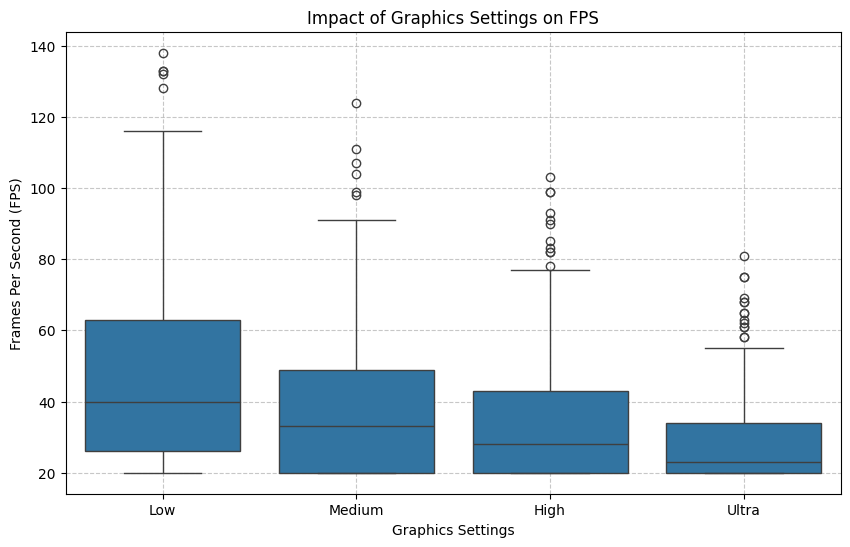

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Graphics_Settings', y='FPS', data=df, order=['Low', 'Medium', 'High', 'Ultra'])
plt.title('Impact of Graphics Settings on FPS')
plt.xlabel('Graphics Settings')
plt.ylabel('Frames Per Second (FPS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    'Linear_Regression_Cleaned': LinearRegression(),
    'Random_Forest_Cleaned': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient_Boosting_Cleaned': GradientBoostingRegressor(random_state=42),
    'XGBoost_Cleaned': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM_Cleaned': LGBMRegressor(random_state=42, n_jobs=-1)
}

results_cleaned = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    pipeline_cleaned = Pipeline(steps=[('preprocessor', preprocessor),
                                      ('regressor', model)])

    pipeline_cleaned.fit(X_train_cleaned, y_train_cleaned)

    y_pred_cleaned = pipeline_cleaned.predict(X_test_cleaned)

    mae_cleaned = mean_absolute_error(y_test_cleaned, y_pred_cleaned)
    mse_cleaned = mean_squared_error(y_test_cleaned, y_pred_cleaned)
    rmse_cleaned = np.sqrt(mse_cleaned)
    r2_cleaned = r2_score(y_test_cleaned, y_pred_cleaned)

    results_cleaned.append({
        'Model': name,
        'MAE': mae_cleaned,
        'MSE': mse_cleaned,
        'RMSE': rmse_cleaned,
        'R2 Score': r2_cleaned
    })
    print(f"{name} - MAE: {mae_cleaned:.2f}, MSE: {mse_cleaned:.2f}, RMSE: {rmse_cleaned:.2f}, R2 Score: {r2_cleaned:.2f}")

comparison_df = pd.DataFrame(results_cleaned)

print("\nModel retraining and evaluation on cleaned data complete.")


Training Linear_Regression_Cleaned...
Linear_Regression_Cleaned - MAE: 10.13, MSE: 160.79, RMSE: 12.68, R2 Score: 0.37

Training Random_Forest_Cleaned...
Random_Forest_Cleaned - MAE: 8.21, MSE: 112.18, RMSE: 10.59, R2 Score: 0.56

Training Gradient_Boosting_Cleaned...
Gradient_Boosting_Cleaned - MAE: 7.91, MSE: 101.23, RMSE: 10.06, R2 Score: 0.60

Training XGBoost_Cleaned...
XGBoost_Cleaned - MAE: 8.15, MSE: 109.71, RMSE: 10.47, R2 Score: 0.57

Training LightGBM_Cleaned...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000776 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 554
[LightGBM] [Info] Number of data points in the train set: 1550, number of used features: 235
[LightGBM] [Info] Start training from score 34.931613
LightGBM_Cleaned - MAE: 7.70, MSE: 99.53, RMSE: 9.98, R2 Score: 0.61

Model retraining and evaluation on cleaned da

**TEST CASE**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# The following lines are removed as X, y, preprocessor are defined in c4c2e050
# X = df.drop(['FPS', 'Upscale'], axis=1)
# y = df['FPS']
# numerical_cols = ['CPU_Score', 'GPU_Score', 'RAM_Size', 'Refresh_Rate']
# categorical_cols = X.select_dtypes(include='object').columns.tolist()
# all_categories = []
# for col in categorical_cols:
#     unique_vals = X[col].unique().tolist()
#     if np.nan in unique_vals:
#         unique_vals.remove(np.nan)
#         unique_vals.append(np.nan)
#     all_categories.append(unique_vals)
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical_cols),
#         ('cat', OneHotEncoder(handle_unknown='ignore', categories=all_categories), categorical_cols)
#     ])
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Redefine Random_Forest_Optimizer (assuming c9f69c3e was executed to get best params)
# To avoid re-running GridSearchCV if it's already done, we can add a check or rely on the sequential execution.
# For now, keeping it here for demonstrative purposes, but in practice, c9f69c3e should define it.
if 'Random_Forest_Optimizer' not in locals() and 'Random_Forest_Optimizer' not in globals():
    param_grid = {
        'regressor__n_estimators': [50, 100, 150],
        'regressor__max_depth': [None, 10, 20],
        'regressor__min_samples_split': [2, 5]
    }
    rf_pipeline_for_tuning = Pipeline(steps=[('preprocessor', preprocessor),
                                           ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])
    grid_search = GridSearchCV(rf_pipeline_for_tuning, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)
    Random_Forest_Optimizer = grid_search.best_estimator_

# Define a sample input scenario for prediction
sample_input_dict = {
    'CPU_Brand': 'Intel', # Added CPU_Brand
    'CPU_Name': 'Core i9-13900K',
    'CPU_Score': 35000,
    'GPU_Brand': 'NVIDIA', # Added GPU_Brand
    'GPU_Name': 'RTX 4090',
    'GPU_Score': 45000,
    'GPU_Type': 'Desktop',
    'VRAM': '24GB',
    'TGP': '450W',
    'RAM_Size': 32,
    'Game_Name': 'Cyberpunk 2077',
    'Resolution': '2560x1440',
    'Refresh_Rate': 144,
    'Graphics_Settings': 'Ultra',
    'Shadow_Quality': 'High',
    'Anti_Aliasing_Mode': 'TAA',
    'Antialiasing_Transparency': '8x',
    'DLSS_FSR': 'Quality',
    'Ray_Tracing': 'High',
    'NVIDIA_Power_Management_Mode': 'Prefer maximum performance',
    'NVIDIA_Low_Latency_Mode': 'Ultra',
    'NVIDIA_Texture_Filtering_Quality': 'High Quality',
    'OS_Game_Mode': 'On',
    'OS_Hardware_Accelerated_GPU_Scheduling': 'On',
    'OS_Power_Plan': 'High Performance',
    'Preferred_Graphics_Processor': 'High-performance NVIDIA processor',
    'Max_Frame_Rate': 'Off',
    'V_Sync': 'Off',
    'Triple_Buffering': 'Off',
    'Shader_Cache_Size': 'Unlimited',
    'Anisotropic_Sample_Optimization': 'On',
    'Threaded_Optimization': 'Auto',
    'Image_Scaling_NIS': 'Off',
    'In_Game_Overlay': 'Disabled',
    'Whisper_Mode': 'Off',
    'Battery_Boost': 'Off',
    'Upscale': 'DLSS 3.5/FSR' # Added Upscale as it's a feature, can be NaN
}

# Create a DataFrame from the sample input, ensuring correct column order
# X.columns represents the feature columns the model was trained on.
predict_df = pd.DataFrame([sample_input_dict]).reindex(columns=X.columns, fill_value='Missing_Category_Placeholder')

# prediction using the tuned model
predicted_fps_single = Random_Forest_Optimizer.predict(predict_df)[0]

print(f"Predicted FPS for the given input scenario: {predicted_fps_single:.2f}")

Predicted FPS for the given input scenario: 23.88


### Hyperparameter Tuning for Random Forest Regressor

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5]
}

# Create a new pipeline for Grid Search
# We'll use a fresh Random Forest Regressor instance to avoid any previous state
rf_pipeline_for_tuning = Pipeline(steps=[('preprocessor', preprocessor),
                                       ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])

# Initialize GridSearchCV
grid_search = GridSearchCV(rf_pipeline_for_tuning, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)

print("Starting Grid Search for Random Forest Regressor...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("\nGrid Search complete.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters found: {best_params}")
print(f"Best R2 Score (cross-validated): {best_score:.4f}")

# Update best_model_pipeline with the best estimator found by GridSearchCV
Random_Forest_Optimizer = grid_search.best_estimator_

print("Updated the best model pipeline with tuned hyperparameters.")

Starting Grid Search for Random Forest Regressor...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Grid Search complete.
Best Parameters found: {'regressor__max_depth': 20, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 150}
Best R2 Score (cross-validated): 0.6800
Updated the best model pipeline with tuned hyperparameters.


### Evaluating the Tuned Random Forest Regressor



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions with the tuned model
y_pred_tuned = Random_Forest_Optimizer.predict(X_test)

# Evaluate the tuned model
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned Random Forest Regressor - MAE: {mae_tuned:.2f}, MSE: {mse_tuned:.2f}, RMSE: {rmse_tuned:.2f}, R2 Score: {r2_tuned:.2f}")

# Add tuned model results to the comparison DataFrame
tuned_rf_results = {
    'Model': 'Random Forest Regressor (Tuned)',
    'MAE': mae_tuned,
    'MSE': mse_tuned,
    'RMSE': rmse_tuned,
    'R2 Score': r2_tuned
}

# Combine all results into a single DataFrame
# 'results' contains models on original data (from 1395f59b)
# 'results_cleaned' contains models on cleaned data (from ec3372ce)
# 'tuned_rf_results' is the tuned model

all_results_df = pd.concat([
    pd.DataFrame(results),
    pd.DataFrame(results_cleaned),
    pd.DataFrame([tuned_rf_results])
], ignore_index=True)

# Assign to full_comparison_df to be used by subsequent cells
full_comparison_df = all_results_df.copy()

display(full_comparison_df.sort_values(by='R2 Score', ascending=False))

Tuned Random Forest Regressor - MAE: 8.60, MSE: 128.49, RMSE: 11.34, R2 Score: 0.67


,Model,MAE,MSE,RMSE,R2 Score
2,Gradient_Boosting,8.356611,110.665011,10.519744,0.717638
8,Random Forest Regressor (Tuned),8.599793,128.486292,11.335179,0.672166
1,Random_Forest,8.586850,129.061738,11.360534,0.670698
7,LightGBM_Cleaned,7.697537,99.532371,9.976591,0.609583
5,Gradient_Boosting_Cleaned,7.914487,101.227896,10.061207,0.602933
6,XGBoost_Cleaned,8.149563,109.708519,10.474183,0.569667
4,Random_Forest_Cleaned,8.213479,112.182304,10.591615,0.559964
0,Linear_Regression,11.596860,205.955059,14.351134,0.474504
3,Linear_Regression_Cleaned,10.130729,160.793263,12.680428,0.369287


### R2 Score comparison of all models

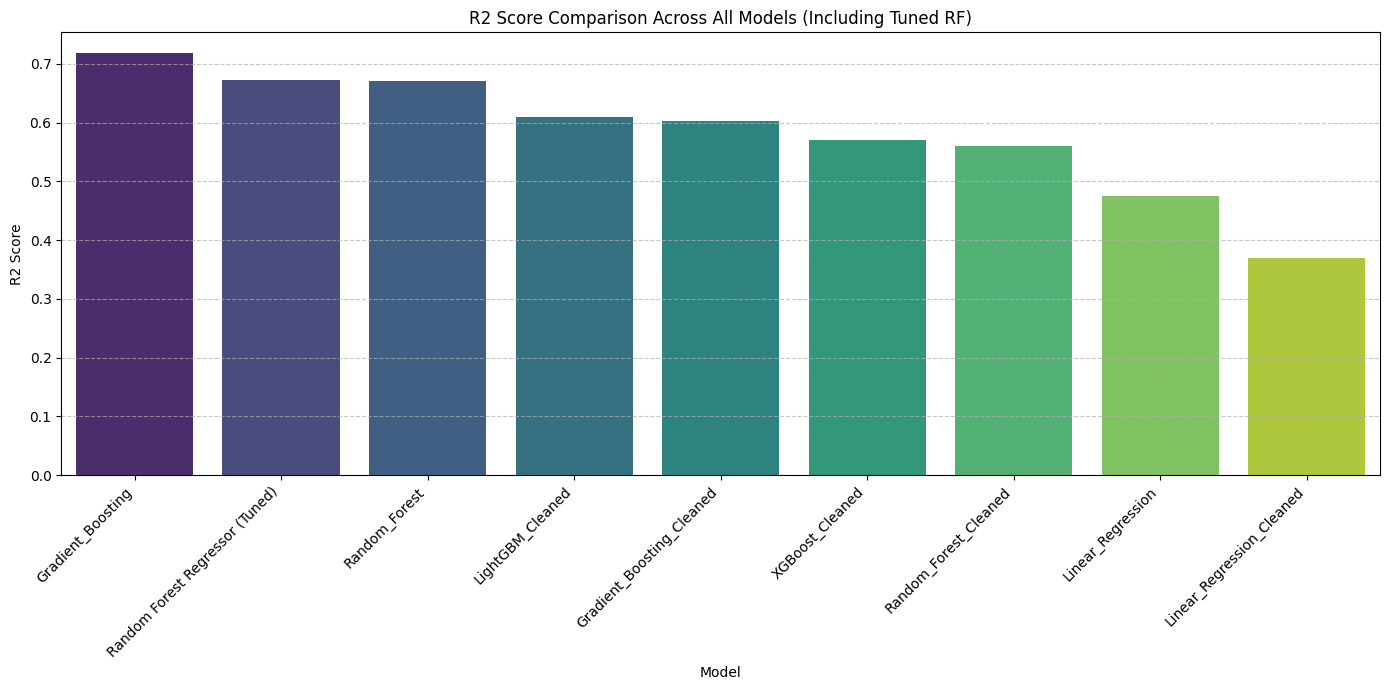

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='R2 Score', data=full_comparison_df.sort_values(by='R2 Score', ascending=False), palette='viridis')
plt.title('R2 Score Comparison Across All Models (Including Tuned RF)')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Test 3

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Redefine Random_Forest_Optimizer (assuming c9f69c3e was executed to get best params)
# To avoid re-running GridSearchCV if it's already done, we can add a check or rely on the sequential execution.
# For now, keeping it here for demonstrative purposes, but in practice, c9f69c3e should define it.
if 'Random_Forest_Optimizer' not in locals() and 'Random_Forest_Optimizer' not in globals():
    param_grid = {
        'regressor__n_estimators': [50, 100, 150],
        'regressor__max_depth': [None, 10, 20],
        'regressor__min_samples_split': [2, 5]
    }
    rf_pipeline_for_tuning = Pipeline(steps=[('preprocessor', preprocessor),
                                           ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])
    grid_search = GridSearchCV(rf_pipeline_for_tuning, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)
    Random_Forest_Optimizer = grid_search.best_estimator_


new_sample_input_dict = {
    'CPU_Brand': 'AMD', # Added CPU_Brand
    'CPU_Name': 'Ryzen 7 5800X',
    'CPU_Score': 25000,
    'GPU_Brand': 'NVIDIA', # Added GPU_Brand
    'GPU_Name': 'RTX 3070',
    'GPU_Score': 22000,
    'GPU_Type': 'Desktop',
    'VRAM': '8GB',
    'TGP': '220W',
    'RAM_Size': 16,
    'Game_Name': 'Elden Ring',
    'Resolution': '2560x1440',
    'Refresh_Rate': 144,
    'Graphics_Settings': 'High',
    'Shadow_Quality': 'Medium',
    'Anti_Aliasing_Mode': 'TAA',
    'Antialiasing_Transparency': '4x',
    'DLSS_FSR': 'Balanced',
    'Ray_Tracing': 'Off',
    'NVIDIA_Power_Management_Mode': 'Prefer maximum performance',
    'NVIDIA_Low_Latency_Mode': 'On',
    'NVIDIA_Texture_Filtering_Quality': 'Quality',
    'OS_Game_Mode': 'On',
    'OS_Hardware_Accelerated_GPU_Scheduling': 'Off',
    'OS_Power_Plan': 'Balanced',
    'Preferred_Graphics_Processor': 'High-performance NVIDIA processor',
    'Max_Frame_Rate': '144',
    'V_Sync': 'Off',
    'Triple_Buffering': 'Off',
    'Shader_Cache_Size': 'Unlimited',
    'Anisotropic_Sample_Optimization': 'On',
    'Threaded_Optimization': 'Auto',
    'Image_Scaling_NIS': 'Off',
    'In_Game_Overlay': 'Disabled',
    'Whisper_Mode': 'Off',
    'Battery_Boost': 'Off',
    'Upscale': 'DLSS 2/FSR' # Added Upscale as it's a feature, can be NaN
}

# Create a DataFrame from the new sample input, ensuring correct column order
# X.columns represents the feature columns the model was trained on.
new_predict_df = pd.DataFrame([new_sample_input_dict]).reindex(columns=X.columns, fill_value='Missing_Category_Placeholder')

# Make the prediction using the tuned model
predicted_fps_new_scenario = Random_Forest_Optimizer.predict(new_predict_df)[0]

print(f"Predicted FPS for the new scenario with tuned model: {predicted_fps_new_scenario:.2f}")

Predicted FPS for the new scenario with tuned model: 32.21


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Redefine Random_Forest_Optimizer (assuming c9f69c3e was executed to get best params)
# To avoid re-running GridSearchCV if it's already done, we can add a check or rely on the sequential execution.
# For now, keeping it here for demonstrative purposes, but in practice, c9f69c3e should define it.
if 'Random_Forest_Optimizer' not in locals() and 'Random_Forest_Optimizer' not in globals():
    param_grid = {
        'regressor__n_estimators': [50, 100, 150],
        'regressor__max_depth': [None, 10, 20],
        'regressor__min_samples_split': [2, 5]
    }
    rf_pipeline_for_tuning = Pipeline(steps=[('preprocessor', preprocessor),
                                           ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])
    grid_search = GridSearchCV(rf_pipeline_for_tuning, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)
    Random_Forest_Optimizer = grid_search.best_estimator_

# Ensure new_sample_input_dict is defined (from previous cell b1814afc)
if 'new_sample_input_dict' not in locals() and 'new_sample_input_dict' not in globals():
    new_sample_input_dict = {
        'CPU_Brand': 'AMD',
        'CPU_Name': 'Ryzen 7 5800X',
        'CPU_Score': 25000,
        'GPU_Brand': 'NVIDIA',
        'GPU_Name': 'RTX 3070',
        'GPU_Score': 22000,
        'GPU_Type': 'Desktop',
        'VRAM': '8GB',
        'TGP': '220W',
        'RAM_Size': 16,
        'Game_Name': 'Elden Ring',
        'Resolution': '2560x1440',
        'Refresh_Rate': 144,
        'Graphics_Settings': 'High',
        'Shadow_Quality': 'Medium',
        'Anti_Aliasing_Mode': 'TAA',
        'Antialiasing_Transparency': '4x',
        'DLSS_FSR': 'Balanced',
        'Ray_Tracing': 'Off',
        'NVIDIA_Power_Management_Mode': 'Prefer maximum performance',
        'NVIDIA_Low_Latency_Mode': 'On',
        'NVIDIA_Texture_Filtering_Quality': 'Quality',
        'OS_Game_Mode': 'On',
        'OS_Hardware_Accelerated_GPU_Scheduling': 'Off',
        'OS_Power_Plan': 'Balanced',
        'Preferred_Graphics_Processor': 'High-performance NVIDIA processor',
        'Max_Frame_Rate': '144',
        'V_Sync': 'Off',
        'Triple_Buffering': 'Off',
        'Shader_Cache_Size': 'Unlimited',
        'Anisotropic_Sample_Optimization': 'On',
        'Threaded_Optimization': 'Auto',
        'Image_Scaling_NIS': 'Off',
        'In_Game_Overlay': 'Disabled',
        'Whisper_Mode': 'Off',
        'Battery_Boost': 'Off',
        'Upscale': 'DLSS 2/FSR'
    }

print(f"--- Optimal Settings Search for {new_sample_input_dict['CPU_Name']} and {new_sample_input_dict['GPU_Name']} ---")
print(f"Game: {new_sample_input_dict['Game_Name']}")

demo_desired_resolution = '2560x1440'
demo_desired_refresh_rate = 144
demo_desired_fps_for_search = 90

recommended_settings_for_new_setup, achieved_fps_for_new_setup = find_optimal_settings(
    cpu_brand=new_sample_input_dict['CPU_Brand'],
    cpu_name=new_sample_input_dict['CPU_Name'],
    cpu_score=new_sample_input_dict['CPU_Score'],
    gpu_brand=new_sample_input_dict['GPU_Brand'],
    gpu_name=new_sample_input_dict['GPU_Name'],
    gpu_score=new_sample_input_dict['GPU_Score'],
    gpu_type=new_sample_input_dict['GPU_Type'],
    vram=new_sample_input_dict['VRAM'],
    tgp=new_sample_input_dict['TGP'],
    ram_size=new_sample_input_dict['RAM_Size'],
    game_name=new_sample_input_dict['Game_Name'],
    desired_resolution=demo_desired_resolution,
    desired_refresh_rate=demo_desired_refresh_rate,
    desired_fps=demo_desired_fps_for_search,
    model_pipeline=Random_Forest_Optimizer,
    X_cols=X.columns
)

if recommended_settings_for_new_setup:
    print(f"\n--- Recommended Settings (Achieved FPS: {achieved_fps_for_new_setup:.2f}) ---")
    for setting, value in recommended_settings_for_new_setup.items():
        print(f"{setting}: {value}")
else:
    print("\nCould not find suitable settings for the given parameters and desired FPS.")

--- Optimal Settings Search for Ryzen 7 5800X and RTX 3070 ---
Game: Elden Ring

--- Recommended Settings (Achieved FPS: 35.56) ---
Shadow_Quality: Medium
Anti_Aliasing_Mode: TAA
Antialiasing_Transparency: 4x
NVIDIA_Power_Management_Mode: Prefer maximum performance
NVIDIA_Low_Latency_Mode: Ultra
NVIDIA_Texture_Filtering_Quality: High performance
OS_Game_Mode: On
OS_Hardware_Accelerated_GPU_Scheduling: On
OS_Power_Plan: Balanced
Preferred_Graphics_Processor: High-performance NVIDIA processor
Triple_Buffering: Off
Shader_Cache_Size: Unlimited
Anisotropic_Sample_Optimization: On
Threaded_Optimization: Auto
Image_Scaling_NIS: Off
In_Game_Overlay: Disabled
Whisper_Mode: Off
Battery_Boost: Off
Graphics_Settings: Low
DLSS_FSR: Balanced
Ray_Tracing: Off
Max_Frame_Rate: Off
V_Sync: Fast


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Redefine Random_Forest_Optimizer (assuming c9f69c3e was executed to get best params)
# To avoid re-running GridSearchCV if it's already done, we can add a check or rely on the sequential execution.
# For now, keeping it here for demonstrative purposes, but in practice, c9f69c3e should define it.
if 'Random_Forest_Optimizer' not in locals() and 'Random_Forest_Optimizer' not in globals():
    param_grid = {
        'regressor__n_estimators': [50, 100, 150],
        'regressor__max_depth': [None, 10, 20],
        'regressor__min_samples_split': [2, 5]
    }
    rf_pipeline_for_tuning = Pipeline(steps=[('preprocessor', preprocessor),
                                           ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])
    grid_search = GridSearchCV(rf_pipeline_for_tuning, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)
    Random_Forest_Optimizer = grid_search.best_estimator_

# --- USER INPUT ---
# Fill in your system's specifications and desired game performance

user_cpu_brand = 'Intel'
user_cpu_name = 'Core i9-14900K'
user_cpu_score = 3125 # You can find this on sites like Geekbench

user_gpu_brand = 'NVIDIA'
user_gpu_name = 'RTX 4080'
user_gpu_score = 250000 # You can find this on sites like PassMark or OpenCL scores
user_gpu_type = 'Desktop' # Or 'Laptop'
user_vram = '16GB'
user_tgp = '320W'

user_ram_size = 32 # in GB
user_game_name = 'Cyberpunk 2077'

user_desired_resolution = '2560x1440'
user_desired_refresh_rate = 144 # in Hz
user_desired_fps = 90 # Your target FPS

# --- END USER INPUT ---

print(f"--- Searching for Optimal Settings for Your Setup ---")
print(f"CPU: {user_cpu_name} (Score: {user_cpu_score})")
print(f"GPU: {user_gpu_name} (Score: {user_gpu_score}), VRAM: {user_vram}, TGP: {user_tgp}")
print(f"RAM: {user_ram_size}GB")
print(f"Game: {user_game_name}")
print(f"Target Resolution: {user_desired_resolution}, Refresh Rate: {user_desired_refresh_rate} Hz, Desired FPS: {user_desired_fps}")
print(f"-----------------------------------------------------")

recommended_settings_user, achieved_fps_user = find_optimal_settings(
    cpu_brand=user_cpu_brand,
    cpu_name=user_cpu_name,
    cpu_score=user_cpu_score,
    gpu_brand=user_gpu_brand,
    gpu_name=user_gpu_name,
    gpu_score=user_gpu_score,
    gpu_type=user_gpu_type,
    vram=user_vram,
    tgp=user_tgp,
    ram_size=user_ram_size,
    game_name=user_game_name,
    desired_resolution=user_desired_resolution,
    desired_refresh_rate=user_desired_refresh_rate,
    desired_fps=user_desired_fps,
    model_pipeline=Random_Forest_Optimizer,
    X_cols=X.columns
)

if recommended_settings_user:
    print(f"\n--- Recommended Settings (Achieved FPS: {achieved_fps_user:.2f}) ---")
    if achieved_fps_user < (user_desired_fps - 5):
        print(f"Warning: Could not achieve desired FPS ({user_desired_fps}). Achieved FPS: {achieved_fps_user:.2f}")
    for setting, value in recommended_settings_user.items():
        print(f"{setting}: {value}")
else:
    print("\nCould not find suitable settings for the given parameters and desired FPS.")

--- Searching for Optimal Settings for Your Setup ---
CPU: Core i9-14900K (Score: 3125)
GPU: RTX 4080 (Score: 250000), VRAM: 16GB, TGP: 320W
RAM: 32GB
Game: Cyberpunk 2077
Target Resolution: 2560x1440, Refresh Rate: 144 Hz, Desired FPS: 90
-----------------------------------------------------

--- Recommended Settings (Achieved FPS: 76.81) ---
Shadow_Quality: Medium
Anti_Aliasing_Mode: TAA
Antialiasing_Transparency: 4x
NVIDIA_Power_Management_Mode: Prefer maximum performance
NVIDIA_Low_Latency_Mode: Ultra
NVIDIA_Texture_Filtering_Quality: High performance
OS_Game_Mode: On
OS_Hardware_Accelerated_GPU_Scheduling: On
OS_Power_Plan: Power Saver
Preferred_Graphics_Processor: High-performance NVIDIA processor
Triple_Buffering: Off
Shader_Cache_Size: Unlimited
Anisotropic_Sample_Optimization: On
Threaded_Optimization: Auto
Image_Scaling_NIS: Off
In_Game_Overlay: Disabled
Whisper_Mode: Off
Battery_Boost: Off
Graphics_Settings: Low
DLSS_FSR: Performance
Ray_Tracing: Off
Max_Frame_Rate: Off
V_Sy

In [ ]:
pip install sheryanalysis==0.1.0

In [ ]:
import sheryanalysis as sh
sh.analyze(df)


🔍 Basic Analysis Report


INFO:sheryanalysis:
🔍 Basic Analysis Report


------------------------------------------------------------


INFO:sheryanalysis:------------------------------------------------------------


📏 Shape: (2000, 37)


...


🔠 Categorical Columns: ['CPU_Brand', 'CPU_Name', 'CPU_Score', 'GPU_Brand', 'GPU_Name', 'GPU_Score', 'GPU_Type', 'VRAM', 'TGP', 'RAM_Size', 'Resolution', 'Refresh_Rate', 'Graphics_Settings', 'Shadow_Quality', 'Anti_Aliasing_Mode', 'Antialiasing_Transparency', 'DLSS_FSR', 'Ray_Tracing', 'NVIDIA_Power_Management_Mode', 'NVIDIA_Low_Latency_Mode', 'NVIDIA_Texture_Filtering_Quality', 'OS_Game_Mode', 'OS_Hardware_Accelerated_GPU_Scheduling', 'OS_Power_Plan', 'Preferred_Graphics_Processor', 'Max_Frame_Rate', 'V_Sync', 'Triple_Buffering', 'Shader_Cache_Size', 'Anisotropic_Sample_Optimization', 'Threaded_Optimization', 'Image_Scaling_NIS', 'In_Game_Overlay', 'Whisper_Mode', 'Battery_Boost', 'FPS']


INFO:sheryanalysis:
🔠 Categorical Columns: ['CPU_Brand', 'CPU_Name', 'CPU_Score', 'GPU_Brand', 'GPU_Name', 'GPU_Score', 'GPU_Type', 'VRAM', 'TGP', 'RAM_Size', 'Resolution', 'Refresh_Rate', 'Graphics_Settings', 'Shadow_Quality', 'Anti_Aliasing_Mode', 'Antialiasing_Transparency', 'DLSS_FSR', 'Ray_Tracing', 'NVIDIA_Power_Management_Mode', 'NVIDIA_Low_Latency_Mode', 'NVIDIA_Texture_Filtering_Quality', 'OS_Game_Mode', 'OS_Hardware_Accelerated_GPU_Scheduling', 'OS_Power_Plan', 'Preferred_Graphics_Processor', 'Max_Frame_Rate', 'V_Sync', 'Triple_Buffering', 'Shader_Cache_Size', 'Anisotropic_Sample_Optimization', 'Threaded_Optimization', 'Image_Scaling_NIS', 'In_Game_Overlay', 'Whisper_Mode', 'Battery_Boost', 'FPS']



📝 Text Columns: ['Game_Name']


INFO:sheryanalysis:
📝 Text Columns: ['Game_Name']


{'shape': (2000, 37),
 'columns': ['CPU_Brand',
  'CPU_Name',
  'CPU_Score',
  'GPU_Brand',
  'GPU_Name',
  'GPU_Score',
  'GPU_Type',
  'VRAM',
  'TGP',
  'RAM_Size',
  'Game_Name',
  'Resolution',
  'Refresh_Rate',
  'Graphics_Settings',
  'Shadow_Quality',
  'Anti_Aliasing_Mode',
  'Antialiasing_Transparency',
  'DLSS_FSR',
  'Ray_Tracing',
  'NVIDIA_Power_Management_Mode',
  'NVIDIA_Low_Latency_Mode',
  'NVIDIA_Texture_Filtering_Quality',
  'OS_Game_Mode',
  'OS_Hardware_Accelerated_GPU_Scheduling',
  'OS_Power_Plan',
  'Preferred_Graphics_Processor',
  'Max_Frame_Rate',
  'V_Sync',
  'Triple_Buffering',
  'Shader_Cache_Size',
  'Anisotropic_Sample_Optimization',
  'Threaded_Optimization',
  'Image_Scaling_NIS',
  'In_Game_Overlay',
  'Whisper_Mode',
  'Battery_Boost',
  'FPS'],
 'dtypes': {'CPU_Brand': dtype('O'),
  'CPU_Name': dtype('O'),
  'CPU_Score': dtype('int64'),
  'GPU_Brand': dtype('O'),
  'GPU_Name': dtype('O'),
  'GPU_Score': dtype('int64'),
  'GPU_Type': dtype('O'),
  

In [ ]:
import joblib

scaler = Random_Forest_Optimizer['preprocessor'].named_transformers_['num']

joblib.dump(Random_Forest_Optimizer, 'Random_Forest_Optimizer.joblib')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']